# Core vs Non-Core Comparison (STRICT Layer)

This notebook summarizes differences between core and non-core works and sources in the OpenAlex STRICT subset.

In [76]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# Centralized plot style
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42


In [77]:
df = pd.read_csv("openalex_works_strict_q1_q3_with_core_flags.csv")
print(df.shape)
print(df[["is_core_work", "is_core_source"]].drop_duplicates())

(5064, 48)
     is_core_work  is_core_source
0               1               1
28              0               1
77              0               0
384             1               0


In [78]:
print (df.columns)

Index(['id', 'doi', 'title', 'abstract_inverted_index', 'publication_year',
       'publication_date', 'open_access', 'type', 'language', 'cited_by_count',
       'primary_location', 'best_oa_location', 'primary_topic', 'topics',
       'locations', 'concepts', 'authorships', 'referenced_works',
       'countries_distinct_count', 'keywords', 'counts_by_year',
       'has_eu_affiliation', 'has_multiple_institutions',
       'distinct_institutions', 'has_multiple_countries', 'distinct_countries',
       'topics_parsed', 'concepts_parsed', 'all_issns', 'issn_list',
       'issn_norm_list', 'has_any_issn', 'num_issn', 'in_scopus_flag',
       'scopus_type', 'sjr_quartile', 'sjr_value', 'h_index_scimago',
       'keep_q1_q3_any', 'is_strict_in_scopus', 'is_strict_q1_q3', 'source_id',
       'work_id_num', 'source_id_num', 'is_core_work', 'core_pub_status',
       'is_core_source', 'core_source_status'],
      dtype='object')


#### Parsing for topics and concepts

In [79]:
# --- Helper to parse list-like columns safely (works for topics or concepts) ---
def parse_list_column(val, keep_top=None):
    """
    Turn a string like "[{...}, {...}]" into a Python list of dicts.
    Optionally keep only the top-k items by 'score'.
    """
    if pd.isna(val):
        return []
    # If it's a string, parse it; if it's already a list, keep it
    if isinstance(val, str):
        try:
            obj = ast.literal_eval(val)
        except Exception:
            return []
    else:
        obj = val

    if not isinstance(obj, list):
        return []

    # Optionally sort by score and keep top-k
    if keep_top is not None:
        obj = sorted(
            obj,
            key=lambda d: d.get("score", 0),
            reverse=True
        )[:keep_top]

    return obj

# Build topics_list and concepts_list columns
df["topics_list"]   = df["topics_parsed"].apply(lambda x: parse_list_column(x, keep_top=5))
df["concepts_list"] = df["concepts_parsed"].apply(lambda x: parse_list_column(x, keep_top=5))

# Quick sanity check
print("Example topics_list entry:\n", df["topics_list"].iloc[0])
print("\nExample concepts_list entry:\n", df["concepts_list"].iloc[0])

Example topics_list entry:
 [{'display_name': 'Artificial Intelligence in Healthcare and Education', 'score': 0.9825000166893005}, {'display_name': 'Topic Modeling', 'score': 0.9814000129699707}, {'display_name': 'Online Learning and Analytics', 'score': 0.9753000140190125}]

Example concepts_list entry:
 [{'display_name': 'Curriculum', 'level': 2, 'score': 0.5452895164489746}, {'display_name': 'Computer science', 'level': 0, 'score': 0.5172855854034424}, {'display_name': 'Field (mathematics)', 'level': 2, 'score': 0.46225565671920776}, {'display_name': 'Engineering ethics', 'level': 1, 'score': 0.4140339493751526}, {'display_name': 'Knowledge management', 'level': 1, 'score': 0.336037814617157}]


### 1. Make sure the flags are booleans + 2×2 crosstab

In [80]:
# ensure flags are 0/1 or True/False
df["is_core_work"] = df["is_core_work"].astype(int)
df["is_core_source"] = df["is_core_source"].astype(int)

# human-readable versions
df["core_work_status"] = df["is_core_work"].map({1: "core work", 0: "non-core work"})
df["core_source_status"] = df["is_core_source"].map({1: "core source", 0: "non-core source"})

# 2×2 crosstab: core_source × core_work
ct_counts = pd.crosstab(df["core_source_status"],
                        df["core_work_status"]) 
ct_pct = ct_counts / ct_counts.values.sum()

print("Counts:")
display(ct_counts)

print("\nPercentages:")
display((ct_pct * 100).round(2))


Counts:


core_work_status,core work,non-core work
core_source_status,,
core source,4338,423
non-core source,21,282



Percentages:


core_work_status,core work,non-core work
core_source_status,,
core source,85.66,8.35
non-core source,0.41,5.57


Figure 1: Crosstab of core vs non-core works and sources (counts and percentages).

### 2. Prepare helper columns: OA, multi-institution, multi-country

In [81]:
import ast
import numpy as np

def extract_is_oa(x):
    if pd.isna(x):
        return 0
    if isinstance(x, dict):
        return int(bool(x.get("is_oa")))
    try:
        d = ast.literal_eval(x)
        if isinstance(d, dict):
            return int(bool(d.get("is_oa")))
    except Exception:
        return 0
    return 0

df["is_oa"] = df["open_access"].apply(extract_is_oa).astype(int)

# ensure multi-institution / multi-country flags are numeric (0/1)
df["has_multiple_institutions"] = df["has_multiple_institutions"].astype(int)
df["has_multiple_countries"] = df["has_multiple_countries"].astype(int)

### 3. Metrics: core works vs non-core works

In [82]:
work_metrics = ["cited_by_count", "is_oa",
                "has_multiple_institutions", "has_multiple_countries"]

core_vs_non = (
    df.groupby("core_work_status")[work_metrics]
      .agg(["mean", "median", "count"])
)

print("Core vs non-core works – summary")
print(core_vs_non)


Core vs non-core works – summary
                 cited_by_count                  is_oa               \
                           mean median count      mean median count   
core_work_status                                                      
core work             31.107593   12.0  4359  0.929571    1.0  4359   
non-core work          6.878014    2.0   705  0.940426    1.0   705   

                 has_multiple_institutions               \
                                      mean median count   
core_work_status                                          
core work                         0.635467    1.0  4359   
non-core work                     0.575887    1.0   705   

                 has_multiple_countries               
                                   mean median count  
core_work_status                                      
core work                      0.414545    0.0  4359  
non-core work                  0.408511    0.0   705  


In [84]:
import pandas as pd
import numpy as np

# --- make sure these columns exist on df ---
# (you already had is_core_work / is_core_source / is_oa)
df["core_work_status"] = df["is_core_work"].map({1: "core work", 0: "non-core work"})
df["core_source_status"] = df["is_core_source"].map({1: "core source", 0: "non-core source"})

metrics = ["cited_by_count", "is_oa", "has_multiple_institutions", "has_multiple_countries"]

# means and medians as SEPARATE tables
core_vs_non_mean = (
    df
    .groupby("core_work_status")[metrics]
    .mean()
    .reset_index()
    .round(2)
)

core_vs_non_median = (
    df
    .groupby("core_work_status")[metrics]
    .median()
    .reset_index()
    .round(2)
)

print("Means – core vs non-core works:")
display(core_vs_non_mean)

print("\nMedians – core vs non-core works:")
display(core_vs_non_median)


Means – core vs non-core works:


,core_work_status,cited_by_count,is_oa,has_multiple_institutions,has_multiple_countries
0,core work,31.11,0.93,0.64,0.41
1,non-core work,6.88,0.94,0.58,0.41



Medians – core vs non-core works:


,core_work_status,cited_by_count,is_oa,has_multiple_institutions,has_multiple_countries
0,core work,12.0,1.0,1.0,0.0
1,non-core work,2.0,1.0,1.0,0.0


#### (B) Citations plot (core vs non-core works)

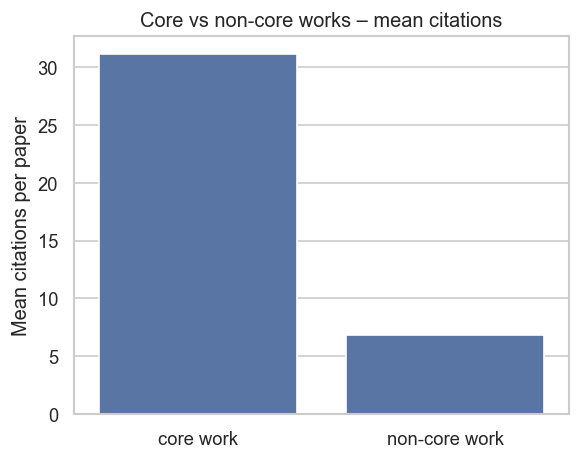

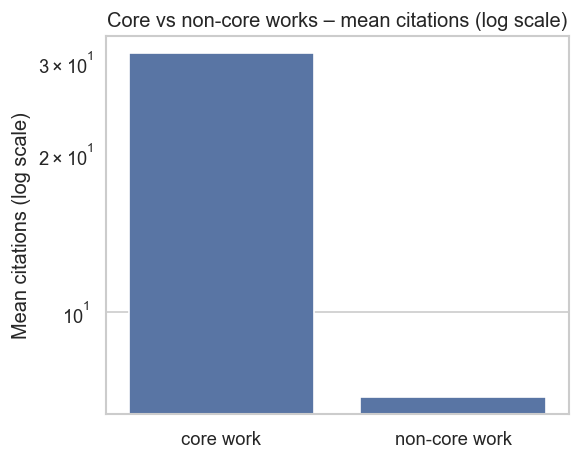

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- prepare small DF for plotting ---
cit_means = (
    df.groupby("core_work_status")["cited_by_count"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(5,4))
sns.barplot(
    data=cit_means,
    x="core_work_status",
    y="cited_by_count"
)
plt.ylabel("Mean citations per paper")
plt.xlabel("")
plt.title("Core vs non-core works – mean citations")
plt.tight_layout()
plt.show()

# OPTIONAL: log scale version (if distribution is very skewed)
plt.figure(figsize=(5,4))
sns.barplot(
    data=cit_means,
    x="core_work_status",
    y="cited_by_count"
)
plt.yscale("log")
plt.ylabel("Mean citations (log scale)")
plt.xlabel("")
plt.title("Core vs non-core works – mean citations (log scale)")
plt.tight_layout()
plt.show()


Figure 2: Mean citations for core vs non-core works. The optional log-scale version highlights skew.

#### (C) Share variables plot (OA, multi-inst, multi-country)

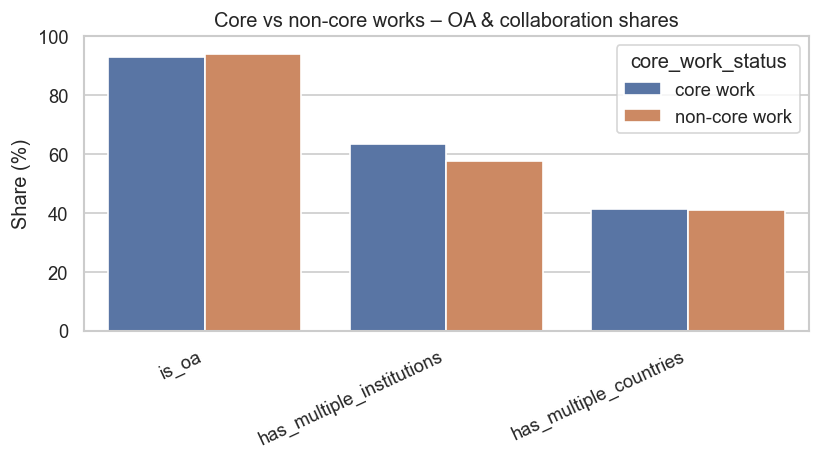

In [86]:
share_cols = ["is_oa", "has_multiple_institutions", "has_multiple_countries"]

shares = (
    df.groupby("core_work_status")[share_cols]
      .mean()
      .reset_index()
)

# convert to percentages
for col in share_cols:
    shares[col] = shares[col] * 100

# melt for seaborn
shares_long = shares.melt(
    id_vars="core_work_status",
    value_vars=share_cols,
    var_name="metric",
    value_name="percent"
)

plt.figure(figsize=(7,4))
sns.barplot(
    data=shares_long,
    x="metric",
    y="percent",
    hue="core_work_status"
)
plt.ylabel("Share (%)")
plt.xlabel("")
plt.ylim(0, 100)
plt.xticks(rotation=25, ha="right")
plt.title("Core vs non-core works – OA & collaboration shares")
plt.legend(title="core_work_status")
plt.tight_layout()
plt.show()


Figure 3: OA, multi-institution, and multi-country shares (%) by core vs non-core works.

### 4. Metrics: works in core vs non-core sources

In [87]:
source_mean = (
    df
    .groupby("core_source_status")[metrics]
    .mean()
    .reset_index()
    .round(2)
)

source_median = (
    df
    .groupby("core_source_status")[metrics]
    .median()
    .reset_index()
    .round(2)
)

print("Means – works in core vs non-core sources:")
display(source_mean)

print("\nMedians – works in core vs non-core sources:")
display(source_median)


Means – works in core vs non-core sources:


,core_source_status,cited_by_count,is_oa,has_multiple_institutions,has_multiple_countries
0,core source,28.92,0.93,0.63,0.42
1,non-core source,9.04,1.00,0.56,0.38



Medians – works in core vs non-core sources:


,core_source_status,cited_by_count,is_oa,has_multiple_institutions,has_multiple_countries
0,core source,10.0,1.0,1.0,0.0
1,non-core source,3.0,1.0,1.0,0.0


#### (A) Summary table

In [88]:
source_metrics = ["cited_by_count", "is_oa",
                  "has_multiple_institutions", "has_multiple_countries"]

core_src_vs_non = (
    df.groupby("core_source_status")[source_metrics]
      .agg(["mean", "median", "count"])
)

print("Works in core vs non-core sources – summary")
print(core_src_vs_non)


Works in core vs non-core sources – summary
                   cited_by_count                  is_oa               \
                             mean median count      mean median count   
core_source_status                                                      
core source             28.924386   10.0  4761  0.926906    1.0  4761   
non-core source          9.036304    3.0   303  0.996700    1.0   303   

                   has_multiple_institutions               \
                                        mean median count   
core_source_status                                          
core source                         0.631380    1.0  4761   
non-core source                     0.561056    1.0   303   

                   has_multiple_countries               
                                     mean median count  
core_source_status                                      
core source                      0.415669    0.0  4761  
non-core source                  0.382838    0.0   303  

#### (B) Citations plot (core vs non-core sources)

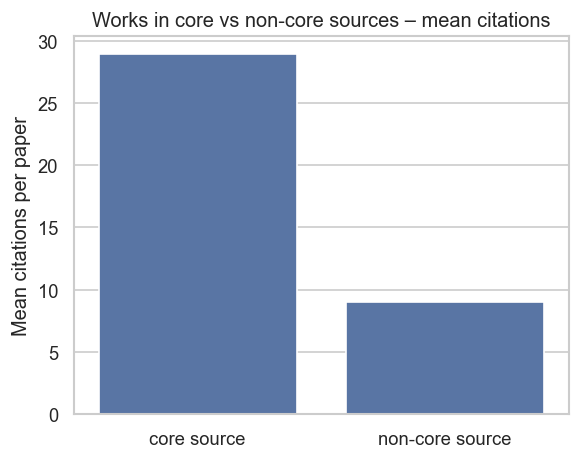

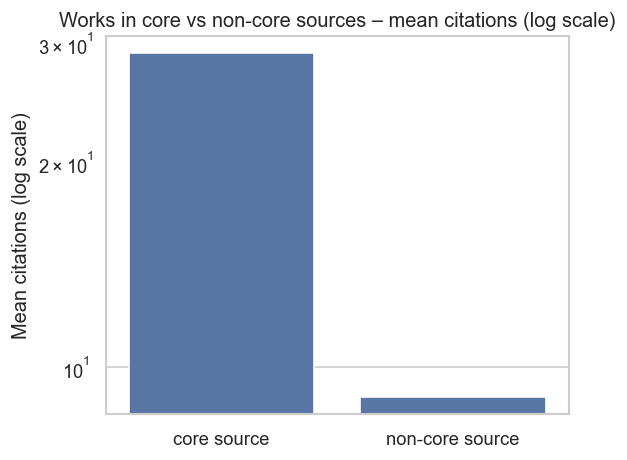

In [89]:
cit_means_src = (
    df.groupby("core_source_status")["cited_by_count"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(5,4))
sns.barplot(
    data=cit_means_src,
    x="core_source_status",
    y="cited_by_count"
)
plt.ylabel("Mean citations per paper")
plt.xlabel("")
plt.title("Works in core vs non-core sources – mean citations")
plt.tight_layout()
plt.show()

# Optional log version
plt.figure(figsize=(5,4))
sns.barplot(
    data=cit_means_src,
    x="core_source_status",
    y="cited_by_count"
)
plt.yscale("log")
plt.ylabel("Mean citations (log scale)")
plt.xlabel("")
plt.title("Works in core vs non-core sources – mean citations (log scale)")
plt.tight_layout()
plt.show()


Figure 4: Mean citations for works in core vs non-core sources (with optional log-scale).

#### (C) Share variables plot (OA, multi-inst, multi-country)

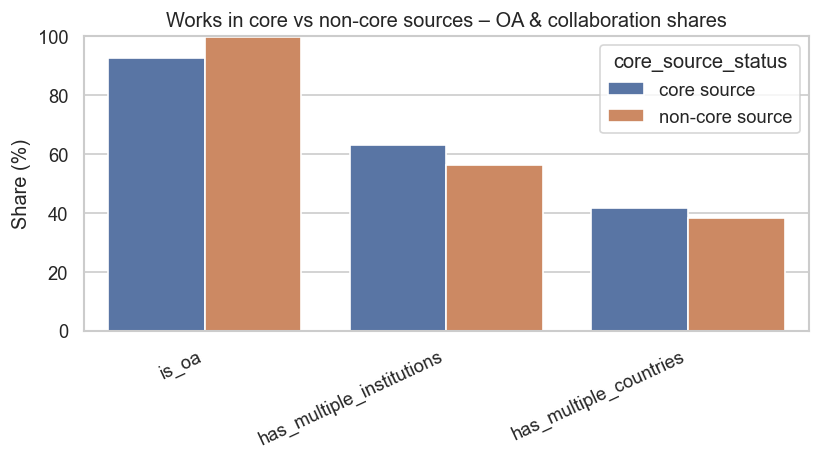

In [90]:
shares_src = (
    df.groupby("core_source_status")[share_cols]
      .mean()
      .reset_index()
)

for col in share_cols:
    shares_src[col] = shares_src[col] * 100

shares_src_long = shares_src.melt(
    id_vars="core_source_status",
    value_vars=share_cols,
    var_name="metric",
    value_name="percent"
)

plt.figure(figsize=(7,4))
sns.barplot(
    data=shares_src_long,
    x="metric",
    y="percent",
    hue="core_source_status"
)
plt.ylabel("Share (%)")
plt.xlabel("")
plt.ylim(0, 100)
plt.xticks(rotation=25, ha="right")
plt.title("Works in core vs non-core sources – OA & collaboration shares")
plt.legend(title="core_source_status")
plt.tight_layout()
plt.show()


Figure 5: OA, multi-institution, and multi-country shares (%) by core vs non-core sources.

### 2×2 crosstab: how concentrated is the core?

In [91]:
import pandas as pd

# df_strict_core is your openalex_works_strict_q1_q3_with_core_flags.csv
# Make sure we have clean labels
df["core_work_status"]   = df["core_pub_status"]      # 'core work' / 'non-core work'
df["core_source_status"] = df["core_source_status"]   # 'core source' / 'non-core source'

# 2×2 crosstab of counts
ct_counts = pd.crosstab(df["core_source_status"], df["core_work_status"])
print("2×2 crosstab – counts:")
print(ct_counts)

# Same but row-normalised percentages
ct_row_pct = pd.crosstab(
    df["core_source_status"],
    df["core_work_status"],
    normalize="index"
) * 100

print("\n2×2 crosstab – row percentages (% within source type):")
print(ct_row_pct.round(1))

# Optional: overall percentages (normalise over all cells)
ct_all_pct = pd.crosstab(
    df["core_source_status"],
    df["core_work_status"],
    normalize=True
) * 100

print("\n2×2 crosstab – overall percentages:")
print(ct_all_pct.round(1))


2×2 crosstab – counts:
core_work_status    core  noncore
core_source_status               
core source         4338      423
non-core source       21      282

2×2 crosstab – row percentages (% within source type):
core_work_status    core  noncore
core_source_status               
core source         91.1      8.9
non-core source      6.9     93.1

2×2 crosstab – overall percentages:
core_work_status    core  noncore
core_source_status               
core source         85.7      8.4
non-core source      0.4      5.6


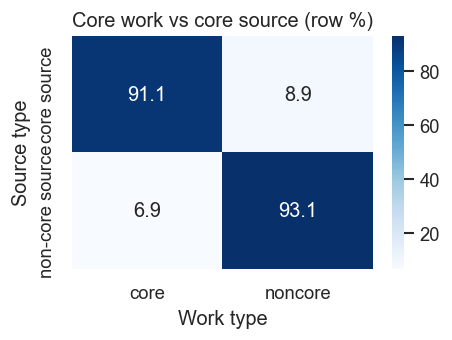

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4,3))
sns.heatmap(ct_row_pct, annot=True, fmt=".1f", cmap="Blues")
plt.title("Core work vs core source (row %)")
plt.ylabel("Source type")
plt.xlabel("Work type")
plt.tight_layout()
plt.show()


Figure 6: Heatmap of row-normalized percentages showing concentration of core works within source types.

### 2. Define a generic “top items” function

In [93]:
from collections import Counter

def top_items_for_subset(subset_df, list_col, n=10, key="display_name"):
    """
    subset_df: filtered dataframe (e.g., core works only)
    list_col : column containing list[dict] (e.g., 'topics_list' or 'concepts_list')
    n        : how many top items to return
    key      : dict key to use as label (usually 'display_name')
    """
    items = []
    for lst in subset_df[list_col]:
        if isinstance(lst, list):
            for d in lst:
                if isinstance(d, dict):
                    name = d.get(key)
                    if name:
                        items.append(name)

    counts = Counter(items)
    if not counts:
        return pd.DataFrame(columns=["item", "count"])

    top = counts.most_common(n)
    return pd.DataFrame(top, columns=["item", "count"])



### 3. Compute top-10 topics for core vs non-core works

In [94]:
# Make sure core_work_status exists
# (You already created this earlier, but re-create just in case)
df["core_work_status"] = np.where(df["is_core_work"] == 1, "core work", "non-core work")

# Split STRICT works into core vs non-core
core_works_df    = df[df["core_work_status"] == "core work"].copy()
noncore_works_df = df[df["core_work_status"] == "non-core work"].copy()

print("Core works:", len(core_works_df), " Non-core works:", len(noncore_works_df))

# --- Top 10 topics for each group ---
top10_topics_core    = top_items_for_subset(core_works_df,    list_col="topics_list",   n=10)
top10_topics_noncore = top_items_for_subset(noncore_works_df, list_col="topics_list",   n=10)

print("\nTop 10 topics – core works")
print(top10_topics_core)

print("\nTop 10 topics – non-core works")
print(top10_topics_noncore)


Core works: 4359  Non-core works: 705

Top 10 topics – core works
                                                item  count
0                      Online Learning and Analytics   1209
1           Innovative Teaching and Learning Methods    514
2                E-Learning and Knowledge Management    366
3                        Online and Blended Learning    363
4  Intelligent Tutoring Systems and Adaptive Lear...    313
5                 Educational Games and Gamification    312
6  Artificial Intelligence in Healthcare and Educ...    239
7                                     Topic Modeling    172
8                  Teaching and Learning Programming    172
9             Educational Innovations and Technology    135

Top 10 topics – non-core works
                                                item  count
0                      Online Learning and Analytics    150
1                E-Learning and Knowledge Management    104
2             Educational Innovations and Technology     87
3 

### 4. Plot the top-10 topics for core vs non-core

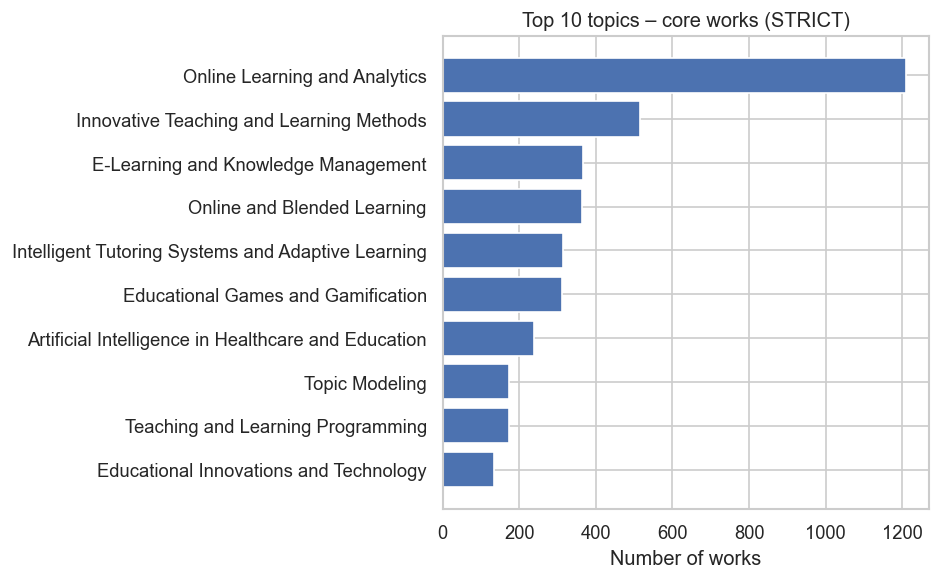

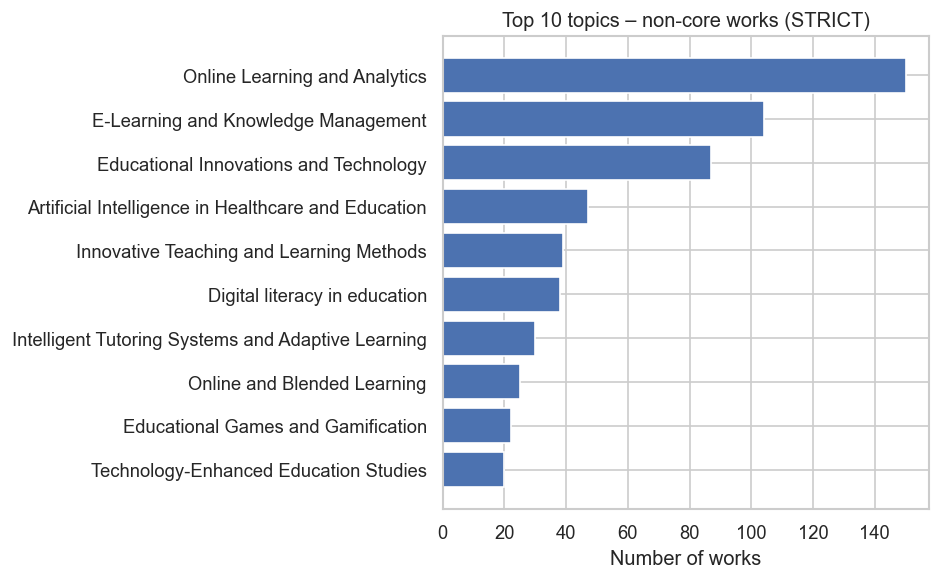

In [95]:
import matplotlib.pyplot as plt

# Core works
plt.figure(figsize=(8, 5))
plt.barh(top10_topics_core["item"], top10_topics_core["count"])
plt.gca().invert_yaxis()
plt.xlabel("Number of works")
plt.title("Top 10 topics – core works (STRICT)")
plt.tight_layout()
plt.show()

# Non-core works
plt.figure(figsize=(8, 5))
plt.barh(top10_topics_noncore["item"], top10_topics_noncore["count"])
plt.gca().invert_yaxis()
plt.xlabel("Number of works")
plt.title("Top 10 topics – non-core works (STRICT)")
plt.tight_layout()
plt.show()


Figure 7: Top 10 topics for core vs non-core works (STRICT).

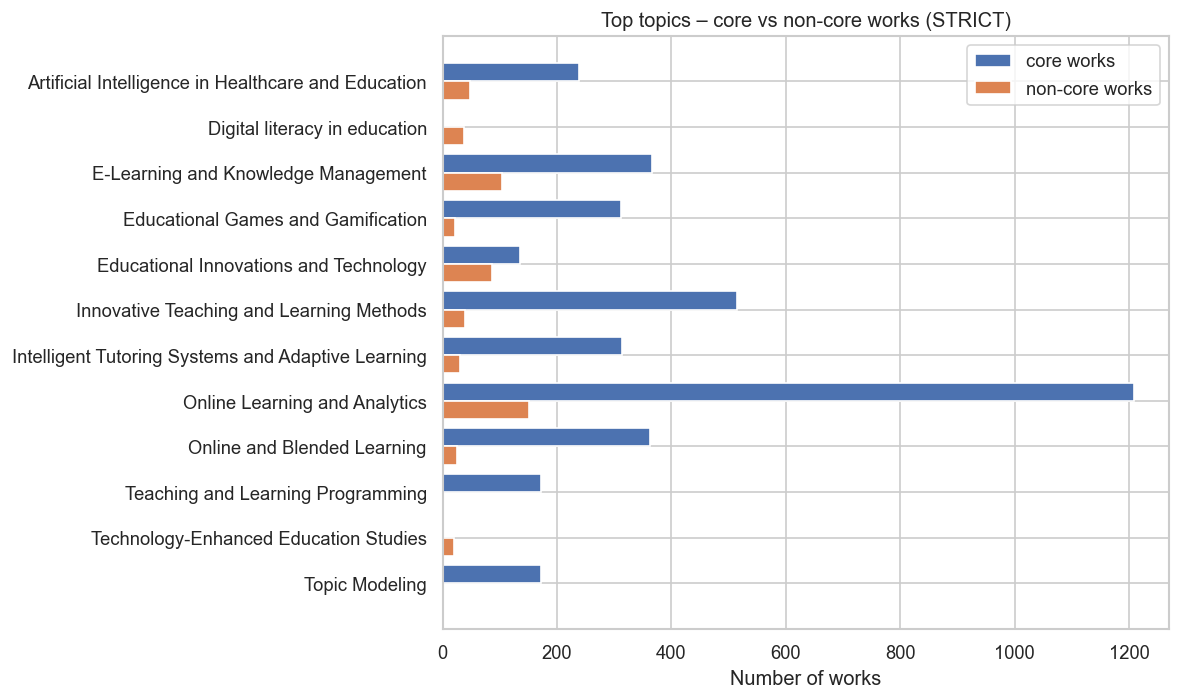

In [96]:
# Merge on topic name so we compare only topics that appear in at least one list
merged_topics = pd.merge(
    top10_topics_core, top10_topics_noncore,
    on="item", how="outer", suffixes=("_core", "_noncore")
).fillna(0)

plt.figure(figsize=(10, 6))
x = range(len(merged_topics))
width = 0.4

plt.barh([i - width/2 for i in x], merged_topics["count_core"],   height=width, label="core works")
plt.barh([i + width/2 for i in x], merged_topics["count_noncore"], height=width, label="non-core works")

plt.yticks(x, merged_topics["item"])
plt.gca().invert_yaxis()
plt.xlabel("Number of works")
plt.title("Top topics – core vs non-core works (STRICT)")
plt.legend()
plt.tight_layout()
plt.show()


Figure 8: Side-by-side comparison of shared top topics across core vs non-core works.

### 5. For concepts

In [97]:
top10_concepts_core    = top_items_for_subset(core_works_df,    list_col="concepts_list", n=10)
top10_concepts_noncore = top_items_for_subset(noncore_works_df, list_col="concepts_list", n=10)


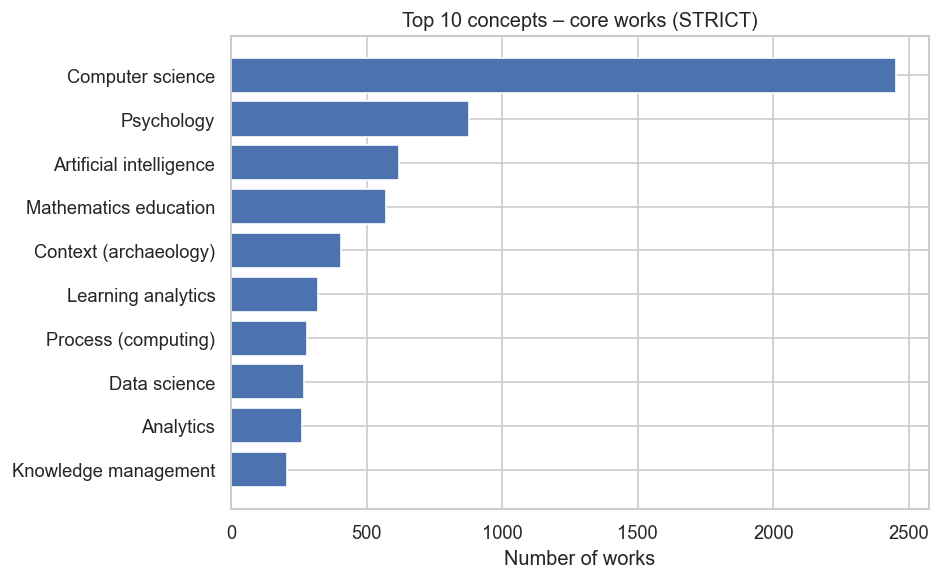

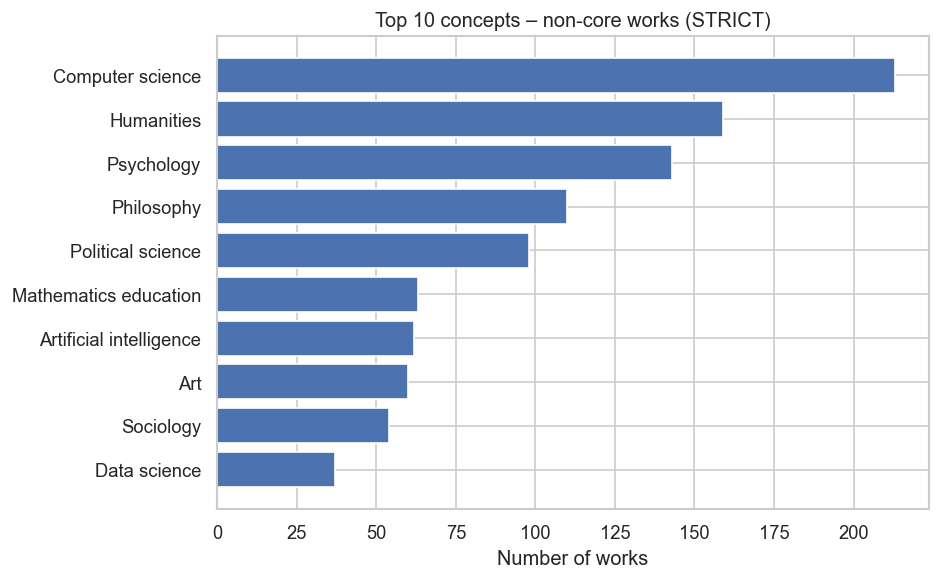

In [98]:
# Core works
plt.figure(figsize=(8, 5))
plt.barh(top10_concepts_core["item"], top10_concepts_core["count"])
plt.gca().invert_yaxis()
plt.xlabel("Number of works")
plt.title("Top 10 concepts – core works (STRICT)")
plt.tight_layout()
plt.show()

# Non-core works
plt.figure(figsize=(8, 5))
plt.barh(top10_concepts_noncore["item"], top10_concepts_noncore["count"])
plt.gca().invert_yaxis()
plt.xlabel("Number of works")
plt.title("Top 10 concepts – non-core works (STRICT)")
plt.tight_layout()
plt.show()

Figure 9: Top 10 concepts for core vs non-core works (STRICT).

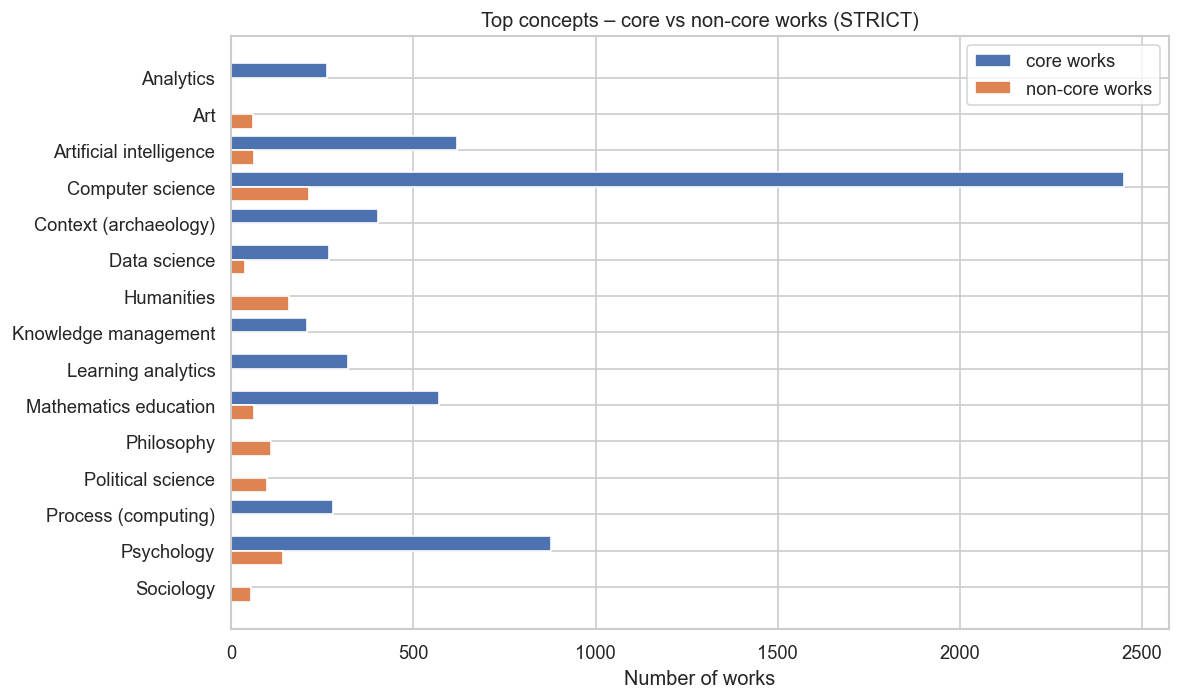

In [99]:
# Merge on concept name so we compare only concepts that appear in at least one list
merged_concepts = pd.merge(
    top10_concepts_core, top10_concepts_noncore,
    on="item", how="outer", suffixes=("_core", "_noncore")
).fillna(0)

plt.figure(figsize=(10, 6))
x = range(len(merged_concepts))
width = 0.4

plt.barh([i - width/2 for i in x], merged_concepts["count_core"],   height=width, label="core works")
plt.barh([i + width/2 for i in x], merged_concepts["count_noncore"], height=width, label="non-core works")
plt.yticks(x, merged_concepts["item"])
plt.gca().invert_yaxis()
plt.xlabel("Number of works")
plt.title("Top concepts – core vs non-core works (STRICT)")
plt.legend()
plt.tight_layout()
plt.show()


Figure 10: Side-by-side comparison of shared top concepts across core vs non-core works.

## Summary & Next Steps

- Core vs non-core works show clear differences in mean citations and OA/collaboration shares.
- The 2×2 crosstab highlights concentration of core works within core sources.
- Top topics and concepts differ between core and non-core subsets, useful for reporting.

Next steps:
- Export key plots and tables for the report.
- Consider stratifying by publication year or venue quartile for deeper insight.
